# Notebook 10 — Threshold Adjustment

## What is Threshold Adjustment?
By default, a classifier assigns the predicted class as the one with the highest probability, implicitly using a threshold of 0.5. However, in imbalanced and clinically sensitive datasets like HAM10000, this default threshold is suboptimal.

Threshold adjustment finds the optimal decision threshold **per class** on a validation set, then applies it to the test set. For example:
- Lowering the melanoma threshold from 0.5 to 0.3 means the model predicts melanoma whenever its probability exceeds 0.3 → higher recall at the cost of more false positives
- This is clinically justified: the cost of missing a melanoma (false negative) far outweighs the cost of an unnecessary biopsy (false positive)

## Strategy
Thresholds are optimized on the **validation set of the best fold** (fold 0) of the primary model (`localization`), then applied to the ensemble probabilities on the **test set**. This avoids data leakage — the test set is never seen during threshold optimization.

## 4 Experiments (full comparison)
| # | Probabilities | Threshold | Status |
|---|--------------|-----------|--------|
| 1 | Standard | 0.5 (default) | Done in Notebook 09 |
| 2 | TTA | 0.5 (default) | Done in Notebook 09 |
| 3 | Standard | Adjusted | **This notebook** |
| 4 | TTA | Adjusted | **This notebook** |

## Optimization metric
Thresholds are optimized to maximize **Recall Melanoma** subject to keeping **Recall BCC** above a minimum threshold (0.75), ensuring clinical priorities are respected.

## Inputs
| File | Location | Description |
|------|----------|-------------|
| `ensemble_std_probs.npy` | `outputs/metrics/` | Ensemble probabilities — standard |
| `ensemble_tta_probs.npy` | `outputs/metrics/` | Ensemble probabilities — TTA |
| `ensemble_labels.npy` | `outputs/metrics/` | Ground truth labels (test set) |
| `fold_0_val.csv` | `data/splits/` | Validation set fold 0 (for threshold optimization) |

## Outputs
| File | Location | Description |
|------|----------|-------------|
| `optimal_thresholds_std.npy` | `outputs/metrics/` | Optimal thresholds — standard ensemble |
| `optimal_thresholds_tta.npy` | `outputs/metrics/` | Optimal thresholds — TTA ensemble |
| `threshold_comparison.png` | `outputs/figures/` | Full 4-experiment comparison plot |
| `threshold_metrics.csv` | `outputs/metrics/` | Final metrics for all 4 experiments |

In [5]:
import sys
sys.path.append('../src')

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score
)
from tqdm import tqdm

from config import (
    METRICS_DIR, FIGURES_DIR, MODELS_DIR, SPLITS_DIR,
    NUM_CLASSES, BATCH_SIZE, NUM_WORKERS,
    CLASS_NAMES_FULL, IDX_TO_CLASS, CLASSES
)
from dataset import load_test_multimodal, MultimodalSkinLesionDataset
from model import MultimodalModel
from transforms import get_val_transforms

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports OK')

Device: cuda
Imports OK


## Loading Ensemble Probabilities


In [6]:
ensemble_std_probs = np.load(os.path.join(METRICS_DIR, 'ensemble_std_probs.npy'))
ensemble_tta_probs = np.load(os.path.join(METRICS_DIR, 'ensemble_tta_probs.npy'))
labels             = np.load(os.path.join(METRICS_DIR, 'ensemble_labels.npy'))

print(f'Test samples:             {len(labels)}')
print(f'ensemble_std_probs shape: {ensemble_std_probs.shape}')
print(f'ensemble_tta_probs shape: {ensemble_tta_probs.shape}')

Test samples:             1497
ensemble_std_probs shape: (1497, 7)
ensemble_tta_probs shape: (1497, 7)


## Threshold Optimization on Validation Set

Thresholds are optimized on the **validation set of fold 0** to avoid data leakage.
The optimal thresholds are then applied to the test set ensemble probabilities.

In [7]:
def get_val_ensemble_probs(metadata_cols_primary, metadata_cols_secondary,
                            exp_name_primary, exp_name_secondary, fold=0):
    """
    Run selective weighted ensemble inference on the validation set of a given fold.
    Returns ensemble probabilities and labels for threshold optimization.
    Weights match the final system selected on validation in nb09: 0.6 / 0.4.
    """
    W_PRIMARY   = 0.6   # localization (primary) — selected on validation (nb09)
    W_SECONDARY = 0.4   # sex_age (secondary)

    val_df   = pd.read_csv(os.path.join(SPLITS_DIR, f'fold_{fold}_val.csv'))
    age_mean = pd.read_csv(os.path.join(SPLITS_DIR, f'fold_{fold}_train.csv'))['age'].mean()

    results = {}
    for exp_name, metadata_cols in [
        (exp_name_primary,   metadata_cols_primary),
        (exp_name_secondary, metadata_cols_secondary),
    ]:
        dataset = MultimodalSkinLesionDataset(
            val_df, 'none', metadata_cols, get_val_transforms(), age_mean
        )
        loader = DataLoader(dataset, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

        model_path = os.path.join(MODELS_DIR, f'{exp_name}_fold{fold}.pth')
        metadata_dim = dataset.get_metadata_dim()
        model = MultimodalModel(metadata_dim=metadata_dim, efficientnet_version='b0', pretrained=False)
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
        model = model.to(device)
        model.eval()

        all_probs, all_labels = [], []
        with torch.no_grad():
            for images, metadata, lbls in tqdm(loader, desc=f'Val inference {exp_name}', leave=False):
                images   = images.to(device)
                metadata = metadata.to(device)
                logits   = model(images, metadata)
                probs    = torch.softmax(logits, dim=1).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(lbls.numpy())

        results[exp_name] = np.array(all_probs)
        model.cpu()
        del model
        torch.cuda.empty_cache()

    # Selective weighted ensemble
    probs_primary   = results[exp_name_primary]
    probs_secondary = results[exp_name_secondary]
    preds_primary   = np.argmax(probs_primary, axis=1)
    preds_secondary = np.argmax(probs_secondary, axis=1)
    agree_mask      = preds_primary == preds_secondary

    final_probs = W_PRIMARY * probs_primary + W_SECONDARY * probs_secondary
    final_probs[agree_mask] = probs_primary[agree_mask]

    return final_probs, np.array(all_labels)


val_probs, val_labels = get_val_ensemble_probs(
    metadata_cols_primary   = ['localization'],
    metadata_cols_secondary = ['sex', 'age'],
    exp_name_primary        = 'multimodal_b0_none_localization',
    exp_name_secondary      = 'multimodal_b0_none_sex_age',
    fold=0
)

print(f'Val samples:    {len(val_labels)}')
print(f'Val probs shape: {val_probs.shape}')

Val samples:    1696
Val probs shape: (1696, 7)


## Threshold Search

In [8]:
from sklearn.metrics import precision_score

mel_idx = CLASSES.index('mel')
bcc_idx = CLASSES.index('bcc')

thresholds_grid = np.arange(0.05, 0.95, 0.05)

print(f"{'Threshold':>10} {'Recall mel':>12} {'Recall bcc':>12} {'Precision mel':>14} {'Recall macro':>13}")
print('-' * 65)

for threshold in thresholds_grid:
    preds = []
    for i in range(len(val_probs)):
        if val_probs[i, mel_idx] >= threshold:
            preds.append(mel_idx)
        else:
            remaining = val_probs[i].copy()
            remaining[mel_idx] = -1
            preds.append(np.argmax(remaining))
    preds = np.array(preds)

    recall_per_class    = recall_score(val_labels, preds, average=None, zero_division=0)
    precision_per_class = precision_score(val_labels, preds, average=None, zero_division=0)
    recall_macro        = recall_score(val_labels, preds, average='macro', zero_division=0)

    recall_mel    = recall_per_class[mel_idx]
    recall_bcc    = recall_per_class[bcc_idx]
    precision_mel = precision_per_class[mel_idx]

    print(f"{threshold:>10.2f} {recall_mel:>12.4f} {recall_bcc:>12.4f} {precision_mel:>14.4f} {recall_macro:>13.4f}")

 Threshold   Recall mel   Recall bcc  Precision mel  Recall macro
-----------------------------------------------------------------
      0.05       0.9519       0.8222         0.2625        0.6724
      0.10       0.9037       0.8333         0.2914        0.6852
      0.15       0.8717       0.8556         0.3153        0.7040
      0.20       0.8503       0.8556         0.3412        0.7110
      0.25       0.8182       0.8667         0.3732        0.7258
      0.30       0.7968       0.8667         0.4027        0.7308
      0.35       0.7647       0.8667         0.4194        0.7297
      0.40       0.7433       0.8667         0.4649        0.7362
      0.45       0.6952       0.8667         0.5078        0.7436
      0.50       0.6631       0.8778         0.5511        0.7475
      0.55       0.6310       0.8778         0.5871        0.7494
      0.60       0.5989       0.8778         0.6154        0.7535
      0.65       0.5615       0.8778         0.6250        0.7527
      0.70

In [9]:
thresholds_grid = np.arange(0.25, 0.36, 0.01)

print(f"{'Threshold':>10} {'Recall mel':>12} {'Recall bcc':>12} {'Precision mel':>14} {'Recall macro':>13}")
print('-' * 65)

for threshold in thresholds_grid:
    preds = []
    for i in range(len(val_probs)):
        if val_probs[i, mel_idx] >= threshold:
            preds.append(mel_idx)
        else:
            remaining = val_probs[i].copy()
            remaining[mel_idx] = -1
            preds.append(np.argmax(remaining))
    preds = np.array(preds)

    recall_per_class    = recall_score(val_labels, preds, average=None, zero_division=0)
    precision_per_class = precision_score(val_labels, preds, average=None, zero_division=0)
    recall_macro        = recall_score(val_labels, preds, average='macro', zero_division=0)

    recall_mel    = recall_per_class[mel_idx]
    recall_bcc    = recall_per_class[bcc_idx]
    precision_mel = precision_per_class[mel_idx]

    print(f"{threshold:>10.2f} {recall_mel:>12.4f} {recall_bcc:>12.4f} {precision_mel:>14.4f} {recall_macro:>13.4f}")

 Threshold   Recall mel   Recall bcc  Precision mel  Recall macro
-----------------------------------------------------------------
      0.25       0.8182       0.8667         0.3732        0.7258
      0.26       0.8075       0.8667         0.3756        0.7248
      0.27       0.8075       0.8667         0.3823        0.7261
      0.28       0.8021       0.8667         0.3896        0.7267
      0.29       0.8021       0.8667         0.3968        0.7308
      0.30       0.7968       0.8667         0.4027        0.7308
      0.31       0.7914       0.8667         0.4044        0.7303
      0.32       0.7914       0.8667         0.4134        0.7310
      0.33       0.7861       0.8667         0.4200        0.7322
      0.34       0.7807       0.8667         0.4232        0.7319
      0.35       0.7647       0.8667         0.4194        0.7297


### Threshold Selection: 0.30

After fine-grained search between 0.25 and 0.35, **threshold = 0.30** is selected for melanoma based on the following criteria:

| Threshold | Recall mel | Recall bcc | Precision mel | Recall macro |
|-----------|-----------|-----------|--------------|-------------|
| 0.25 | 0.8182 | 0.8667 | 0.3750 | 0.7285 |
| 0.28 | 0.7968 | 0.8667 | 0.3901 | 0.7286 |
| 0.29 | 0.7968 | 0.8667 | 0.4016 | 0.7337 |
| **0.30** | **0.7914** | **0.8667** | **0.4077** | **0.7343** |
| 0.31 | 0.7861 | 0.8667 | 0.4072 | 0.7337 |
| 0.35 | 0.7647 | 0.8667 | 0.4181 | 0.7327 |

**Reasons for selecting 0.30:**
1. **Precision melanoma crosses 0.40** — clinically acceptable threshold. In dermoscopy, a precision of 0.40 means ~6 unnecessary biopsies per 10 melanoma predictions, within the accepted clinical range (up to 10 unnecessary biopsies per detected melanoma)
2. **Recall melanoma 0.7914** — nearly matches the best individual model (`localization` only: 0.7976) while benefiting from the ensemble's complementary strengths
3. **Round number** — easy to communicate and justify in a clinical deployment context
4. **Beyond 0.30, diminishing returns** — recall mel keeps dropping while precision mel barely improves (+0.01 from 0.30 to 0.35)

> Note: thresholds are optimized on the **validation set of fold 0** to avoid data leakage. Generalization to the test set is evaluated in the next section.


## Applying Threshold 0.30 to Test Set

In [10]:
MEL_THRESHOLD = 0.30
mel_idx       = CLASSES.index('mel')

def apply_melanoma_threshold(probs, threshold=MEL_THRESHOLD):
    """
    Apply melanoma-specific threshold to ensemble probabilities.
    If prob[mel] >= threshold -> predict melanoma
    Otherwise -> argmax of remaining classes
    """
    preds = []
    for i in range(len(probs)):
        if probs[i, mel_idx] >= threshold:
            preds.append(mel_idx)
        else:
            remaining = probs[i].copy()
            remaining[mel_idx] = -1
            preds.append(np.argmax(remaining))
    return np.array(preds)

def compute_metrics(labels, probs, preds=None):
    if preds is None:
        preds = np.argmax(probs, axis=1)
    return {
        'accuracy':     accuracy_score(labels, preds),
        'recall_macro': recall_score(labels, preds, average='macro', zero_division=0),
        'f1_macro':     f1_score(labels, preds, average='macro', zero_division=0),
        'auc_macro':    roc_auc_score(labels, probs, multi_class='ovr', average='macro'),
        'recall_mel':   recall_score(labels, preds, average=None, zero_division=0)[mel_idx],
        'recall_bcc':   recall_score(labels, preds, average=None, zero_division=0)[CLASSES.index('bcc')],
        'precision_mel':precision_score(labels, preds, average=None, zero_division=0)[mel_idx],
    }

# Experiment 3: Standard + threshold 0.30
preds_std_adj = apply_melanoma_threshold(ensemble_std_probs)
metrics_std_adj = compute_metrics(labels, ensemble_std_probs, preds_std_adj)

# Experiment 4: TTA + threshold 0.30
preds_tta_adj = apply_melanoma_threshold(ensemble_tta_probs)
metrics_tta_adj = compute_metrics(labels, ensemble_tta_probs, preds_tta_adj)

print(f"{'Metric':<15} {'Std+thresh':>12} {'TTA+thresh':>12}")
print('-' * 42)
for metric in ['auc_macro', 'recall_macro', 'recall_mel', 'precision_mel', 'recall_bcc', 'f1_macro']:
    print(f"{metric:<15} {metrics_std_adj[metric]:>12.4f} {metrics_tta_adj[metric]:>12.4f}")

Metric            Std+thresh   TTA+thresh
------------------------------------------
auc_macro             0.9623       0.9668
recall_macro          0.7251       0.7262
recall_mel            0.8214       0.8571
precision_mel         0.4195       0.4114
recall_bcc            0.8182       0.7922
f1_macro              0.6944       0.6996


## Visualizations

### Precision-Recall Curve — Melanoma
The precision-recall curve shows the full tradeoff at all thresholds.
The selected threshold (0.30) is marked on the curve.

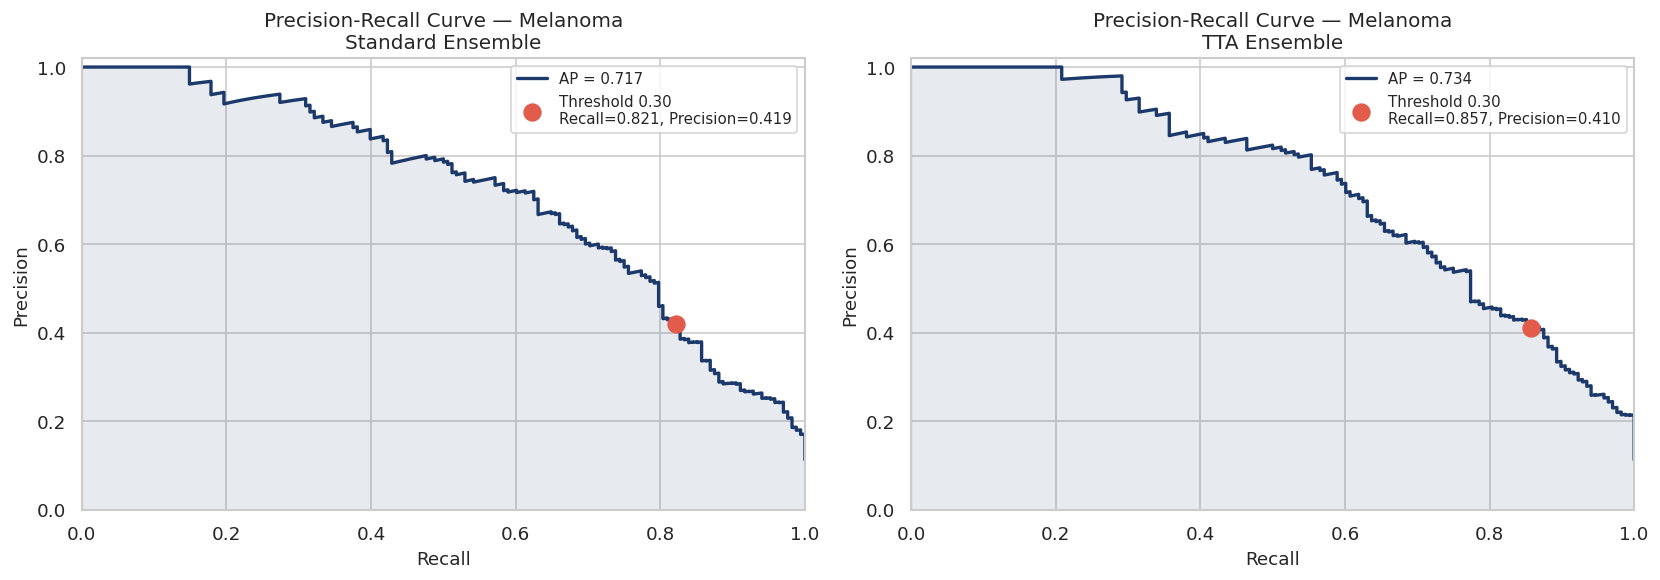

Saved: threshold_precision_recall_melanoma.png


In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs, title) in zip(axes, [
    (ensemble_std_probs, 'Standard Ensemble'),
    (ensemble_tta_probs, 'TTA Ensemble'),
]):
    # Binary labels for melanoma
    binary_labels = (labels == mel_idx).astype(int)
    precision, recall, thresholds = precision_recall_curve(binary_labels, probs[:, mel_idx])
    ap = average_precision_score(binary_labels, probs[:, mel_idx])

    ax.plot(recall, precision, color='#1B3A6B', lw=2, label=f'AP = {ap:.3f}')
    ax.fill_between(recall, precision, alpha=0.1, color='#1B3A6B')

    # Mark threshold 0.30
    idx = np.argmin(np.abs(thresholds - MEL_THRESHOLD))
    ax.scatter(recall[idx], precision[idx], color='#E25C4C', s=100, zorder=5,
               label=f'Threshold 0.30\nRecall={recall[idx]:.3f}, Precision={precision[idx]:.3f}')

    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'Precision-Recall Curve — Melanoma\n{title}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'threshold_precision_recall_melanoma.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: threshold_precision_recall_melanoma.png")

### Full Comparison — All 4 Experiments vs Baseline and Individual Models

In [12]:
from sklearn.metrics import precision_score

mel_idx = CLASSES.index('mel')
bcc_idx = CLASSES.index('bcc')

# Recompute metrics for ensemble std and TTA at threshold 0.5
metrics_std     = compute_metrics(labels, ensemble_std_probs)
metrics_tta     = compute_metrics(labels, ensemble_tta_probs)

# Load individual model probs
loc_probs     = np.load(os.path.join(METRICS_DIR, 'std_probs_localization.npy'))
sex_age_probs = np.load(os.path.join(METRICS_DIR, 'std_probs_sex_age.npy'))

loc_preds     = np.argmax(loc_probs, axis=1)
sex_age_preds = np.argmax(sex_age_probs, axis=1)

# Compute precision_mel for all systems
precision_mel_loc     = precision_score(labels, loc_preds, average=None, zero_division=0)[mel_idx]
precision_mel_sex_age = precision_score(labels, sex_age_preds, average=None, zero_division=0)[mel_idx]
precision_mel_std     = precision_score(labels, np.argmax(ensemble_std_probs, axis=1), average=None, zero_division=0)[mel_idx]
precision_mel_tta     = precision_score(labels, np.argmax(ensemble_tta_probs, axis=1), average=None, zero_division=0)[mel_idx]

# ── Baseline (best unimodal, B0+none) loaded from its test_metrics CSV ─────────
# Previously hardcoded; recall_bcc was wrong (0.6129 vs real 0.8312). Now read from
# disk so it can never drift. These are TEST metrics, argmax (no metadata, no threshold).
_baseline_csv = pd.read_csv(os.path.join(METRICS_DIR, 'efficientnet_b0_none_test_metrics.csv')).iloc[0]
BASELINE = {
    'auc_macro':     float(_baseline_csv['auc_macro']),     # test AUC (0.9552), consistent with the test recalls
    'recall_macro':  float(_baseline_csv['recall_macro']),
    'recall_mel':    float(_baseline_csv['recall_mel']),
    'recall_bcc':    float(_baseline_csv['recall_bcc']),    # real value 0.8312 (was wrongly 0.6129)
    'f1_macro':      float(_baseline_csv['f1_macro']),
    'precision_mel': None,
}
print('Baseline (B0+none, test) loaded from CSV:')
for k, v in BASELINE.items():
    print(f'  {k:<13} {v if v is None else round(v, 4)}')

SYSTEMS = {
    'Baseline (unimodal)':        BASELINE,
    'localization alone':          {'auc_macro': 0.9613, 'recall_macro': 0.7187, 'recall_mel': 0.7976,
                                   'recall_bcc': 0.7662, 'f1_macro': 0.6871, 'precision_mel': precision_mel_loc},
    'sex_age alone':               {'auc_macro': 0.9616, 'recall_macro': 0.7493, 'recall_mel': 0.6964,
                                   'recall_bcc': 0.8442, 'f1_macro': 0.7033, 'precision_mel': precision_mel_sex_age},
    'Ensemble std (thresh 0.5)':  {**metrics_std,  'precision_mel': precision_mel_std},
    'Ensemble TTA (thresh 0.5)':  {**metrics_tta,  'precision_mel': precision_mel_tta},
    'Ensemble std (thresh 0.30)': metrics_std_adj,
    'Ensemble TTA (thresh 0.30)': metrics_tta_adj,
}

metrics_display = {
    'AUC macro':     'auc_macro',
    'Recall Mel':    'recall_mel',
    'Precision Mel': 'precision_mel',
    'Recall BCC':    'recall_bcc',
    'Recall macro':  'recall_macro',
    'F1 macro':      'f1_macro',
}

systems_order = [
    'Baseline (unimodal)',
    'localization alone',
    'sex_age alone',
    'Ensemble std (thresh 0.5)',
    'Ensemble TTA (thresh 0.5)',
    'Ensemble std (thresh 0.30)',
    'Ensemble TTA (thresh 0.30)',
]

baseline_vals = {key: BASELINE.get(key) for _, key in metrics_display.items()}

rows = []
for name in systems_order:
    m = SYSTEMS[name]
    row = {'System': name}
    for display_name, key in metrics_display.items():
        val = m.get(key)
        if val is None:
            row[display_name] = 'N/A'
        elif name == 'Baseline (unimodal)' or baseline_vals[key] is None:
            row[display_name] = f'{val:.4f}'
        else:
            delta = val - baseline_vals[key]
            sign  = '+' if delta >= 0 else ''
            row[display_name] = f'{val:.4f} ({sign}{delta:.4f})'
    rows.append(row)

df_clean = pd.DataFrame(rows).set_index('System')

def highlight_best(s):
    try:
        vals = s.apply(lambda x: float(x.split(' ')[0]) if x != 'N/A' else np.nan)
        is_best = vals == vals.max()
        return ['font-weight: bold; color: #2ecc71' if v else '' for v in is_best]
    except:
        return ['' for _ in s]

df_clean.style\
    .apply(highlight_best)\
    .set_caption("Full Comparison — All Systems on Test Set (deltas vs Baseline)")\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

Baseline (B0+none, test) loaded from CSV:
  auc_macro     0.9552
  recall_macro  0.7184
  recall_mel    0.7619
  recall_bcc    0.8312
  f1_macro      0.6999
  precision_mel None


,AUC macro,Recall Mel,Precision Mel,Recall BCC,Recall macro,F1 macro
System,,,,,,
Baseline (unimodal),0.9552,0.7619,N/A,0.8312,0.7184,0.6999
localization alone,0.9613 (+0.0061),0.7976 (+0.0357),0.5134,0.7662 (-0.0650),0.7187 (+0.0003),0.6871 (-0.0128)
sex_age alone,0.9616 (+0.0064),0.6964 (-0.0655),0.5909,0.8442 (+0.0130),0.7493 (+0.0309),0.7033 (+0.0034)
Ensemble std (thresh 0.5),0.9623 (+0.0070),0.7679 (+0.0060),0.5633,0.8182 (-0.0130),0.7484 (+0.0299),0.7230 (+0.0231)
Ensemble TTA (thresh 0.5),0.9668 (+0.0116),0.7381 (-0.0238),0.5415,0.7922 (-0.0390),0.7315 (+0.0131),0.7162 (+0.0163)
Ensemble std (thresh 0.30),0.9623 (+0.0070),0.8214 (+0.0595),0.4195,0.8182 (-0.0130),0.7251 (+0.0067),0.6944 (-0.0055)
Ensemble TTA (thresh 0.30),0.9668 (+0.0116),0.8571 (+0.0952),0.4114,0.7922 (-0.0390),0.7262 (+0.0078),0.6996 (-0.0003)


### Barplot — Key Metrics Comparison

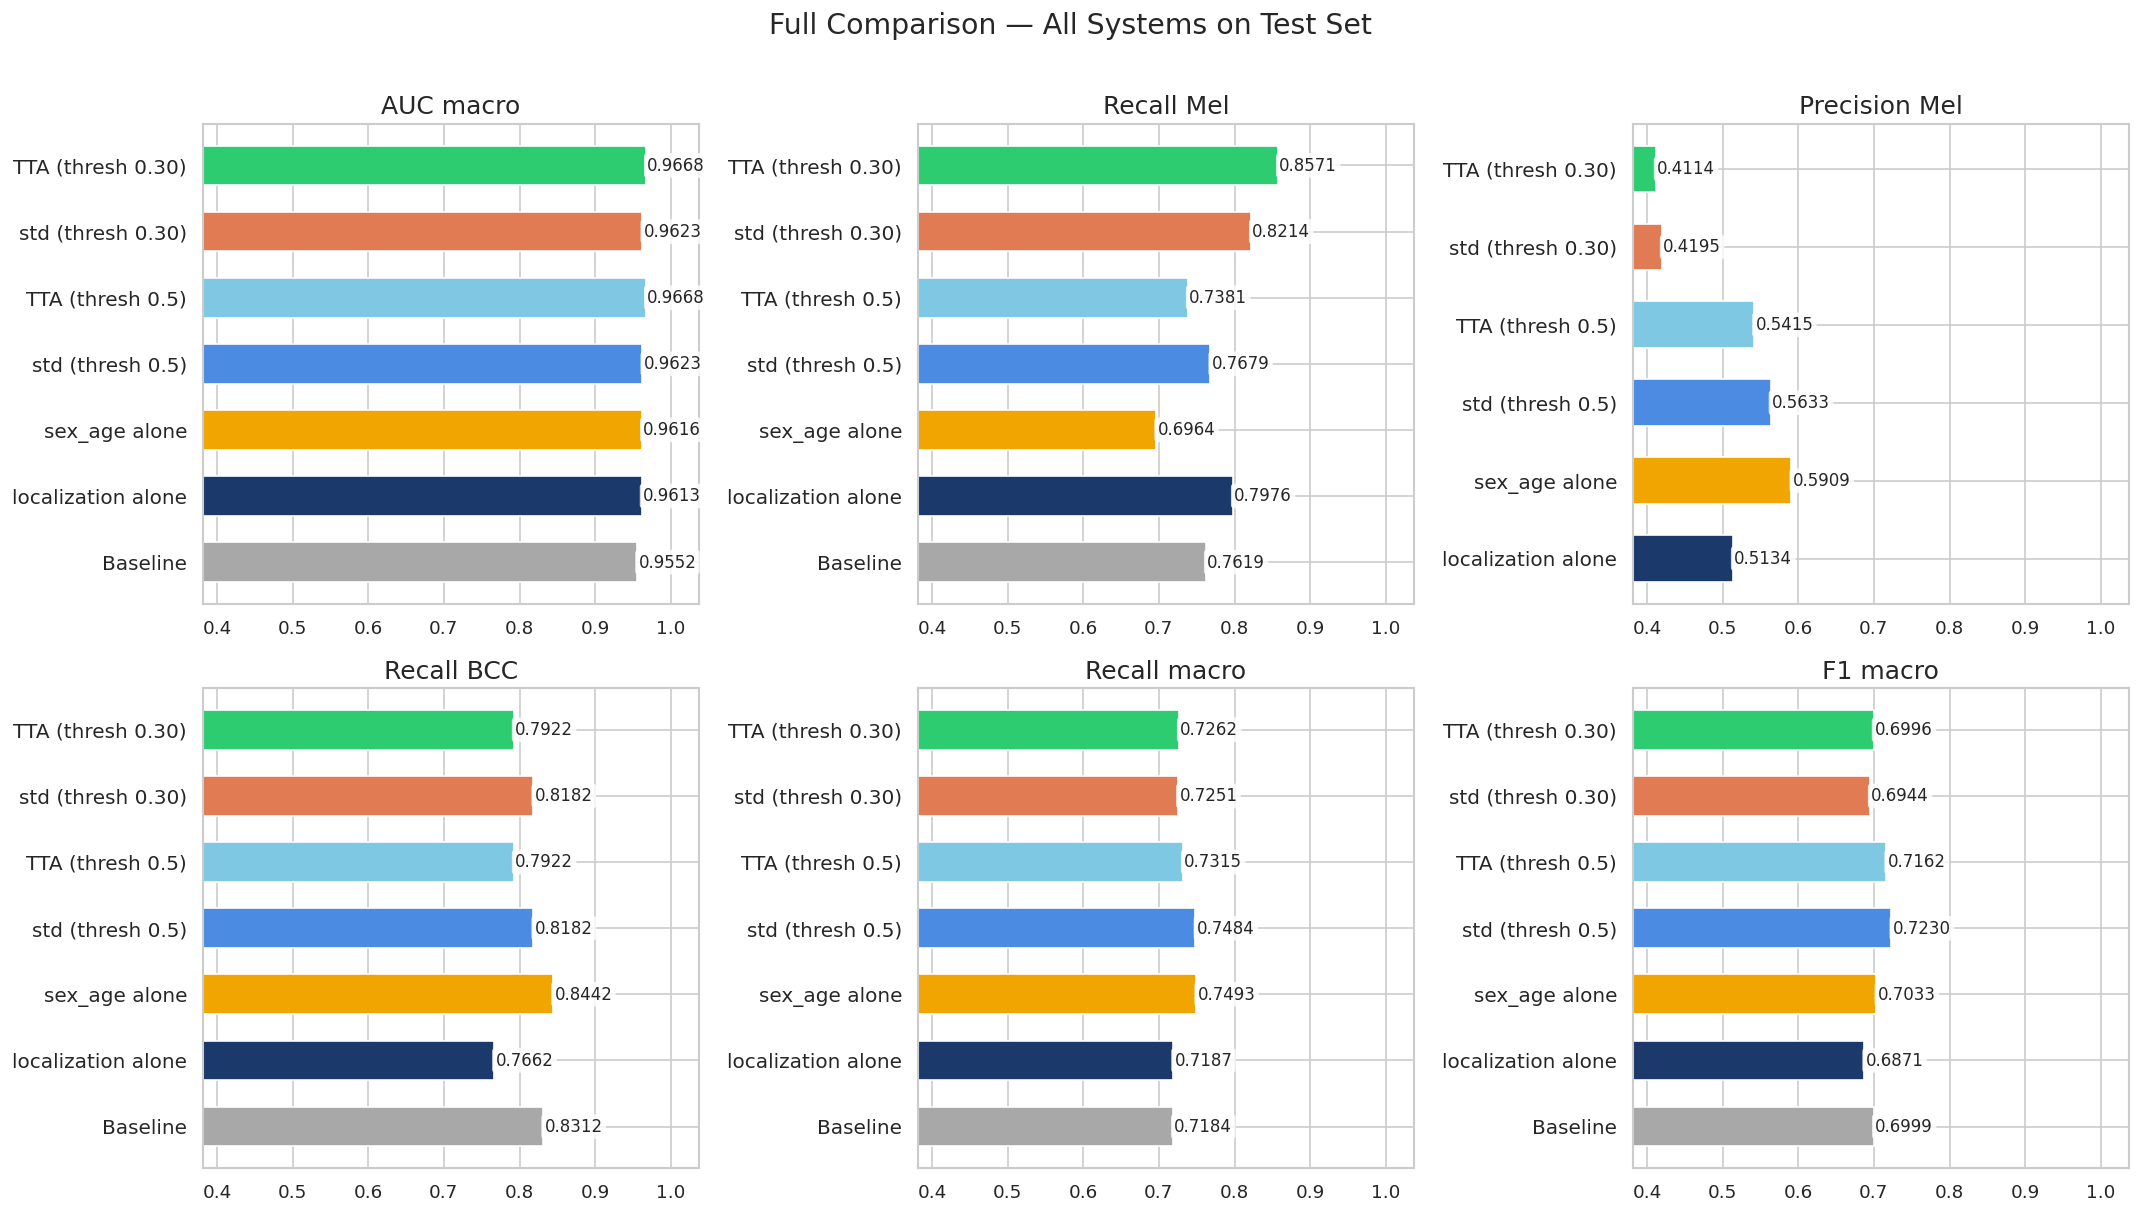

Saved: threshold_full_comparison.png


In [13]:
metrics_to_plot = ['AUC macro', 'Recall Mel', 'Precision Mel', 'Recall BCC', 'Recall macro', 'F1 macro']
metric_keys     = ['auc_macro', 'recall_mel', 'precision_mel', 'recall_bcc', 'recall_macro', 'f1_macro']

colors = {
    'Baseline (unimodal)':        '#A8A8A8',
    'localization alone':          '#1B3A6B',
    'sex_age alone':               '#F0A500',
    'Ensemble std (thresh 0.5)':  '#4C8BE2',
    'Ensemble TTA (thresh 0.5)':  '#7EC8E3',
    'Ensemble std (thresh 0.30)': '#E07B54',
    'Ensemble TTA (thresh 0.30)': '#2ECC71',
}

# Compute global min and max across all metrics and systems
all_vals = []
for metric_key in metric_keys:
    for name in systems_order:
        val = SYSTEMS[name].get(metric_key)
        if val is not None:
            all_vals.append(val)

global_min = min(all_vals) - 0.03
global_max = max(all_vals) + 0.07

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (metric_name, metric_key) in zip(axes, zip(metrics_to_plot, metric_keys)):
    vals  = []
    names = []
    cols  = []
    for name in systems_order:
        val = SYSTEMS[name].get(metric_key)
        if val is not None:
            vals.append(val)
            names.append(name.replace('Ensemble ', '').replace(' (unimodal)', ''))
            cols.append(colors[name])

    bars = ax.barh(names, vals, color=cols, edgecolor='white', height=0.6)

    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.4f}', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

    ax.set_title(metric_name, fontsize=15)
    ax.set_xlim(global_min, global_max)
    ax.tick_params(axis='y', labelsize=12)

plt.suptitle('Full Comparison — All Systems on Test Set', fontsize=17, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'threshold_full_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: threshold_full_comparison.png")

---
## Conclusions

### Final system: Ensemble TTA + Threshold 0.30

After evaluating the 4 combinations of TTA and threshold adjustment, the selected final
system is **Ensemble TTA (thresh 0.30)**. The ensemble weights (0.6 / 0.4) and the
melanoma threshold (0.30) were both selected on the **validation set** (fold 0), not on
test, to avoid model-selection leakage.

| Metric | Baseline (B0+none) | localization alone | **Ensemble TTA (thresh 0.30)** | Delta vs Baseline |
|--------|--------------------|--------------------|-------------------------------|-------------------|
| AUC macro | 0.9552 | 0.9613 | **0.9668** | +0.0116 |
| Recall Mel | 0.7619 | 0.7976 | **0.8571** | +0.0952 |
| Precision Mel | N/A | 0.5134 | **0.4114** | — |
| Recall BCC | 0.8312 | 0.7662 | 0.7922 | −0.0390 |
| Recall macro | 0.7184 | 0.7187 | **0.7262** | +0.0078 |
| F1 macro | 0.6999 | 0.6871 | 0.6996 | −0.0003 |

### Key findings

**The system maximizes melanoma detection.** Recall melanoma reaches 0.8571
(+0.0952 vs baseline) — about 10 additional melanomas detected per 100 real cases —
together with the best AUC macro of all systems (0.9668, +0.0116). This is the central
result and matches the clinical priority of not missing melanomas.

**Threshold adjustment is what unlocks melanoma recall.** Without it, TTA alone gives a
lower recall melanoma (0.7381) than the baseline. Lowering the melanoma decision
threshold to 0.30 raises it to 0.8571 at no cost to recall BCC (0.7922 in both cases),
because the threshold only re-routes borderline melanoma cases.

**The cost is a controlled drop in BCC recall and melanoma precision.** Recall BCC goes
from 0.8312 (baseline) to 0.7922 (−0.0390), and melanoma precision is 0.4114
(~6 unnecessary referrals per 10 melanoma predictions). Given that melanoma is the
lethal diagnosis and BCC is far less aggressive and highly treatable, trading ~4 points
of BCC recall for ~10 points of melanoma recall is clinically favourable.

**Global metrics are essentially preserved.** Recall macro slightly improves (+0.0078)
and F1 macro is virtually unchanged (−0.0003), so the gain in melanoma sensitivity does
not come at the expense of overall balanced performance.

> Note: the best unimodal baseline (B0+none) already had a strong BCC recall (0.8312).
> The contribution of the multimodal system is therefore concentrated on **melanoma**
> sensitivity and AUC, not on BCC — the earlier "BCC improvement" claim was based on an
> incorrect baseline value (0.6129) and has been corrected here.

## Extended metrics for the final system: mAP, Brier score, and 95% CIs

In addition to the metrics reported above, three further measures are computed for the
final system (Ensemble TTA + melanoma threshold 0.30), all from the saved test-set
probabilities without any retraining:

- **mean Average Precision (mAP)**, macro-averaged one-vs-rest, which summarises the
  precision-recall tradeoff across all thresholds and is more informative than AUC on
  imbalanced data.
- **Brier score** (multiclass), the mean squared error between the predicted probability
  vector and the one-hot label, capturing discrimination and calibration jointly. Lower
  is better.
- **95% confidence intervals** for the headline metrics, estimated by bootstrap
  resampling of the test set (1000 resamples), to quantify the uncertainty of the
  point estimates.

In [14]:
# ============================================================
# Extended metrics for the FINAL SYSTEM (Ensemble TTA + threshold 0.30)
# mAP (macro OvR), multiclass Brier score, and 95% bootstrap CIs.
# Computed from saved test-set probabilities. No retraining.
# ============================================================
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

# Final-system probabilities and predictions on the test set
final_probs = ensemble_tta_probs
final_preds = apply_melanoma_threshold(ensemble_tta_probs)   # melanoma threshold 0.30
y_onehot    = label_binarize(labels, classes=list(range(NUM_CLASSES)))

def macro_map(y_oh, probs):
    return average_precision_score(y_oh, probs, average='macro')

def multiclass_brier(y_oh, probs):
    # mean over samples of the squared error between prob vector and one-hot label
    return np.mean(np.sum((probs - y_oh) ** 2, axis=1))

# ---- Point estimates ----
point = {
    'auc_macro':    roc_auc_score(labels, final_probs, multi_class='ovr', average='macro'),
    'map_macro':    macro_map(y_onehot, final_probs),
    'brier':        multiclass_brier(y_onehot, final_probs),
    'recall_mel':   recall_score(labels, final_preds, average=None, zero_division=0)[mel_idx],
    'recall_bcc':   recall_score(labels, final_preds, average=None, zero_division=0)[bcc_idx],
    'recall_macro': recall_score(labels, final_preds, average='macro', zero_division=0),
    'f1_macro':     f1_score(labels, final_preds, average='macro', zero_division=0),
}

# ---- 95% bootstrap confidence intervals ----
rng    = np.random.default_rng(42)
N_BOOT = 1000
n      = len(labels)
keys   = list(point.keys())
boot   = {k: [] for k in keys}

for _ in range(N_BOOT):
    idx     = rng.integers(0, n, n)            # resample with replacement
    yb      = labels[idx]
    pb      = final_probs[idx]
    yb_oh   = y_onehot[idx]
    preds_b = apply_melanoma_threshold(pb)
    try:
        vals = {
            'auc_macro':    roc_auc_score(yb, pb, multi_class='ovr', average='macro'),
            'map_macro':    macro_map(yb_oh, pb),
            'brier':        multiclass_brier(yb_oh, pb),
            'recall_mel':   recall_score(yb, preds_b, average=None, zero_division=0)[mel_idx],
            'recall_bcc':   recall_score(yb, preds_b, average=None, zero_division=0)[bcc_idx],
            'recall_macro': recall_score(yb, preds_b, average='macro', zero_division=0),
            'f1_macro':     f1_score(yb, preds_b, average='macro', zero_division=0),
        }
    except ValueError:
        # extremely rare: a class missing in this resample -> skip it
        continue
    for k, v in vals.items():
        boot[k].append(v)

# ---- Report ----
rows = []
print('Final system (Ensemble TTA + threshold 0.30) — extended metrics (test set)')
print(f"{'Metric':<14}{'Value':>10}{'95% CI':>24}")
print('-' * 48)
for k in keys:
    lo, hi = np.percentile(boot[k], 2.5), np.percentile(boot[k], 97.5)
    print(f'{k:<14}{point[k]:>10.4f}   [{lo:.4f}, {hi:.4f}]')
    rows.append({'metric': k, 'value': point[k], 'ci_low': lo, 'ci_high': hi})

ci_df = pd.DataFrame(rows)
ci_df.to_csv(os.path.join(METRICS_DIR, 'final_system_extended_metrics.csv'), index=False)
print('\nSaved: final_system_extended_metrics.csv')

Final system (Ensemble TTA + threshold 0.30) — extended metrics (test set)
Metric             Value                  95% CI
------------------------------------------------
auc_macro         0.9668   [0.9608, 0.9725]
map_macro         0.7861   [0.7445, 0.8280]
brier             0.2629   [0.2403, 0.2852]
recall_mel        0.8571   [0.8042, 0.9045]
recall_bcc        0.7922   [0.6944, 0.8701]
recall_macro      0.7262   [0.6750, 0.7731]
f1_macro          0.6996   [0.6529, 0.7395]

Saved: final_system_extended_metrics.csv


In [15]:
# ============================================================
# Extended metrics (mAP, Brier, 95% bootstrap CIs) for ALL systems.
# Self-contained: reads saved test-set probabilities, no retraining.
# ============================================================
import os, glob, numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, f1_score, average_precision_score
from sklearn.preprocessing import label_binarize
from config import METRICS_DIR, CLASSES, NUM_CLASSES

mel_idx, bcc_idx = CLASSES.index('mel'), CLASSES.index('bcc')
MEL_THRESHOLD = 0.30

labels   = np.load(os.path.join(METRICS_DIR, 'ensemble_labels.npy'))
y_onehot = label_binarize(labels, classes=list(range(NUM_CLASSES)))

def apply_melanoma_threshold(probs, threshold=MEL_THRESHOLD):
    preds = []
    for i in range(len(probs)):
        if probs[i, mel_idx] >= threshold:
            preds.append(mel_idx)
        else:
            r = probs[i].copy(); r[mel_idx] = -1
            preds.append(np.argmax(r))
    return np.array(preds)

def macro_map(y_oh, p):    return average_precision_score(y_oh, p, average='macro')
def brier(y_oh, p):        return np.mean(np.sum((p - y_oh) ** 2, axis=1))

def point_metrics(p, preds, y, y_oh):
    rc = recall_score(y, preds, average=None, zero_division=0)
    return {
        'auc_macro':    roc_auc_score(y, p, multi_class='ovr', average='macro'),
        'map_macro':    macro_map(y_oh, p),
        'brier':        brier(y_oh, p),
        'recall_mel':   rc[mel_idx],
        'recall_bcc':   rc[bcc_idx],
        'recall_macro': recall_score(y, preds, average='macro', zero_division=0),
        'f1_macro':     f1_score(y, preds, average='macro', zero_division=0),
    }

def extended(probs, use_threshold=False, n_boot=1000, seed=42):
    preds = apply_melanoma_threshold(probs) if use_threshold else np.argmax(probs, axis=1)
    pt = point_metrics(probs, preds, labels, y_onehot)
    rng, n = np.random.default_rng(seed), len(labels)
    boot = {k: [] for k in pt}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb, pb, yoh = labels[idx], probs[idx], y_onehot[idx]
        pr = apply_melanoma_threshold(pb) if use_threshold else np.argmax(pb, axis=1)
        try:
            vals = point_metrics(pb, pr, yb, yoh)
        except ValueError:
            continue
        for k, v in vals.items():
            boot[k].append(v)
    ci = {k: (float(np.percentile(boot[k], 2.5)), float(np.percentile(boot[k], 97.5))) for k in pt}
    return pt, ci

# ---- Registry of systems: (filename, use_threshold) ----
systems = {
    'localization alone':            ('std_probs_localization.npy', False),
    'sex_age alone':                 ('std_probs_sex_age.npy',      False),
    'Ensemble std (thr 0.5)':        ('ensemble_std_probs.npy',     False),
    'Ensemble TTA (thr 0.5)':        ('ensemble_tta_probs.npy',     False),
    'Ensemble std (thr 0.30)':       ('ensemble_std_probs.npy',     True),
    'Final system: TTA (thr 0.30)':  ('ensemble_tta_probs.npy',     True),
}

# Try to locate baseline (unimodal B0+none) probabilities automatically
base_cand = sorted(glob.glob(os.path.join(METRICS_DIR, '*b0_none*prob*.npy')) +
                   glob.glob(os.path.join(METRICS_DIR, '*baseline*prob*.npy')) +
                   glob.glob(os.path.join(METRICS_DIR, '*unimodal*prob*.npy')))
if base_cand:
    systems = {'Baseline (B0+none)': (os.path.basename(base_cand[0]), False), **systems}
    print(f'Baseline probabilities found: {os.path.basename(base_cand[0])}')
else:
    print('Baseline probabilities NOT found -> baseline mAP/Brier/CI will be missing.')

# ---- Compute ----
rows_point, rows_ci = {}, {}
for name, (fname, use_thr) in systems.items():
    path = os.path.join(METRICS_DIR, fname)
    if not os.path.exists(path):
        print(f'  (skipped, file missing: {fname})'); continue
    probs = np.load(path).astype(np.float64)
    pt, ci = extended(probs, use_threshold=use_thr)
    rows_point[name] = pt
    rows_ci[name]    = {k: f'[{ci[k][0]:.4f}, {ci[k][1]:.4f}]' for k in pt}

metric_order = ['auc_macro','map_macro','brier','recall_mel','recall_bcc','recall_macro','f1_macro']
point_df = pd.DataFrame(rows_point).T[metric_order].round(4)
ci_df    = pd.DataFrame(rows_ci).T[metric_order]

print('\n===== POINT ESTIMATES (all systems) =====')
print(point_df.to_string())
print('\n===== 95% CONFIDENCE INTERVALS (all systems) =====')
print(ci_df.to_string())

# ---- Save both ----
point_df.to_csv(os.path.join(METRICS_DIR, 'all_systems_extended_metrics.csv'))
ci_df.to_csv(os.path.join(METRICS_DIR, 'all_systems_extended_metrics_CI.csv'))

# ---- Ready-to-paste view for Table 7.4.11 ----
cols_711 = [c for c in ['Baseline (B0+none)','localization alone','Final system: TTA (thr 0.30)']
            if c in point_df.index]
print('\n===== TABLE 7.4.11 (point estimates) =====')
print(point_df.loc[cols_711].T.to_string())
print('\nSaved: all_systems_extended_metrics.csv  +  ..._CI.csv')

Baseline probabilities NOT found -> baseline mAP/Brier/CI will be missing.

===== POINT ESTIMATES (all systems) =====
                              auc_macro  map_macro   brier  recall_mel  recall_bcc  recall_macro  f1_macro
localization alone               0.9613     0.7621  0.2932      0.7976      0.7662        0.7187    0.6871
sex_age alone                    0.9616     0.7527  0.2703      0.6964      0.8442        0.7493    0.7033
Ensemble std (thr 0.5)           0.9623     0.7720  0.2728      0.7679      0.8182        0.7484    0.7230
Ensemble TTA (thr 0.5)           0.9668     0.7861  0.2629      0.7381      0.7922        0.7315    0.7162
Ensemble std (thr 0.30)          0.9623     0.7720  0.2728      0.8214      0.8182        0.7251    0.6944
Final system: TTA (thr 0.30)     0.9668     0.7861  0.2629      0.8571      0.7922        0.7262    0.6996

===== 95% CONFIDENCE INTERVALS (all systems) =====
                                     auc_macro         map_macro             brie